# Image classification


## Diabetic Retionpathy dataset

In [1]:
%pip install kagglehub
%pip install tensorflow
%pip install ultralytics

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import os
import kagglehub

import numpy as np
import csv
import cv2 as cv
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns
import random
from tensorflow.keras.applications.resnet50 import preprocess_input


import warnings
warnings.filterwarnings('ignore')

- download the provided dataset:

In [3]:
# Set dataset path
dataset_path = kagglehub.dataset_download("jockeroika/diabetic-retinopathy")

The dataset used in this project is a Diabetic Retinopathy dataset by the Asia Pacific Tele-Ophtalmology Society (APTOS) in 2019. It differentiates between 5 different classes of stages in DR, displayed by fundus photography.



## Data Analysis

In [4]:
# Number of samples and classes
classes = list(os.listdir(dataset_path))
num_classes = len(classes)
print('Classes:', classes)
print(num_classes)


Classes: ['Healthy', 'Mild DR', 'Moderate DR', 'Proliferate DR', 'Severe DR']
5


These are the five different classes in the dataset:
- Healthy
- Mild DR
- Moderate DR
- Proliferate DR
- Severe DR


Image count per class:
Healthy: 525
Mild DR: 370
Moderate DR: 599
Proliferate DR: 290
Severe DR: 202


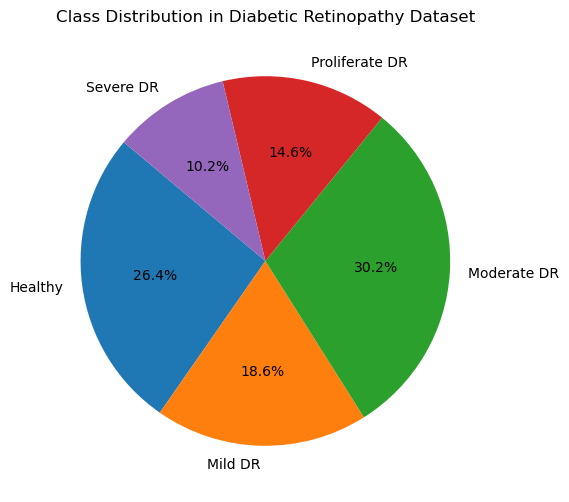

In [5]:
# Show the class distribution of
class_counts = {}
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.png'))
        ])

print("\nImage count per class:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

# Create pie chart
labels = list(class_counts.keys())
sizes = list(class_counts.values())

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title("Class Distribution in Diabetic Retinopathy Dataset")
plt.show()

It is visible, that the dataset is clearly not evenly distributed between the different classes. This is a potential reason why models dont perform so well on certain classes in the future, and is thus important to notice.

There are more photos of healthy or mildly affected retinas, then there are of gravely affected ones.

In [6]:
# Get the size of the images from one random image
# This is required for the image preprocessing later
from PIL import Image
import os

path = f"{dataset_path}\\Healthy"  

for filename in os.listdir(path):
    if filename.lower().endswith(('.png')):
        img_path = os.path.join(path, filename)
        with Image.open(img_path) as img:
            width, height = img.size
            print(f"{filename}: {width}x{height}")
        break


Healthy.png: 256x256


## Preprocessing

In [7]:
# Get the data from the different kaggle folders and split it
# For reproducibility, just skip this code, and load the split from below
# Otherwise the random split can influence the results significantly
# Parameters
"""
data_dir = dataset_path  # Set directory to kagglehub dataset path
img_height, img_width = 256, 256
batch_size = 32 # Use smaller batch_size to run the models more efficiently
seed_value = 42 # Set one seed value

# Collect file names and labels
filepaths = []
labels = []

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        for fname in os.listdir(class_path):
            if fname.lower().endswith(('.png')):
                filepaths.append(os.path.join(class_path, fname))
                labels.append(class_name)

# Create a DataFrame to split the data
df = pd.DataFrame({'filename': filepaths, 'class': labels})

# Split data the data into 70% train and 30% temp 
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['class'], random_state=seed_value
)

# Second split: validation (15%) and test (15%) from temp
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['class'], random_state=seed_value
)

print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")
"""

'\ndata_dir = dataset_path  # Set directory to kagglehub dataset path\nimg_height, img_width = 256, 256\nbatch_size = 32 # Use smaller batch_size to run the models more efficiently\nseed_value = 42 # Set one seed value\n\n# Collect file names and labels\nfilepaths = []\nlabels = []\n\nfor class_name in os.listdir(data_dir):\n    class_path = os.path.join(data_dir, class_name)\n    if os.path.isdir(class_path):\n        for fname in os.listdir(class_path):\n            if fname.lower().endswith((\'.png\')):\n                filepaths.append(os.path.join(class_path, fname))\n                labels.append(class_name)\n\n# Create a DataFrame to split the data\ndf = pd.DataFrame({\'filename\': filepaths, \'class\': labels})\n\n# Split data the data into 70% train and 30% temp \ntrain_df, temp_df = train_test_split(\n    df, test_size=0.3, stratify=df[\'class\'], random_state=seed_value\n)\n\n# Second split: validation (15%) and test (15%) from temp\nval_df, test_df = train_test_split(\n    

In [8]:
# Save the partition
"""
train_df.to_csv('train_split.csv', index=False)
val_df.to_csv('val_split.csv', index=False)
test_df.to_csv('test_split.csv', index=False)
"""

"\ntrain_df.to_csv('train_split.csv', index=False)\nval_df.to_csv('val_split.csv', index=False)\ntest_df.to_csv('test_split.csv', index=False)\n"

In [11]:
# Load the partition
# (Should be done now, with the data provided from me)
img_height, img_width = 256, 256
batch_size = 32 # Use smaller batch_size to run the models more efficiently
seed_value = 42 # Set one seed value
train_df = pd.read_csv('train_split.csv')
val_df = pd.read_csv('val_split.csv')
test_df = pd.read_csv('test_split.csv')


In [12]:
# ImageDataGenerators with ResNet50 preprocessing (because I will use it later as a pretrained model, and it is needed in order to achieve a good performance)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,   # ResNet50 expects inputs preprocessed in a specific way
    rotation_range=10, # Randomly rotate images in the range +/- 10 degrees
    width_shift_range=0.1, # Randomly translate images horizontally by up to 10% of total width
    height_shift_range=0.1, # Randomly translate images vertically by up to 10% of total height
    horizontal_flip=True, # Randomly flip half of the images horizontally during training
    fill_mode='nearest' # When pixels are shifted out of frame, fill with nearest pixel values
)

# Dont preprocess the test or validation set, as this has to be close realworld images
test_val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)


# Flow from DataFrame
# Create the three different Generators for the split dataset
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',
    y_col='class',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    seed=seed_value
)

val_generator = test_val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filename',
    y_col='class',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
    seed=seed_value
)

test_generator = test_val_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filename',
    y_col='class',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
    seed=seed_value
)


Found 1390 validated image filenames belonging to 5 classes.
Found 298 validated image filenames belonging to 5 classes.
Found 298 validated image filenames belonging to 5 classes.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..146.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].


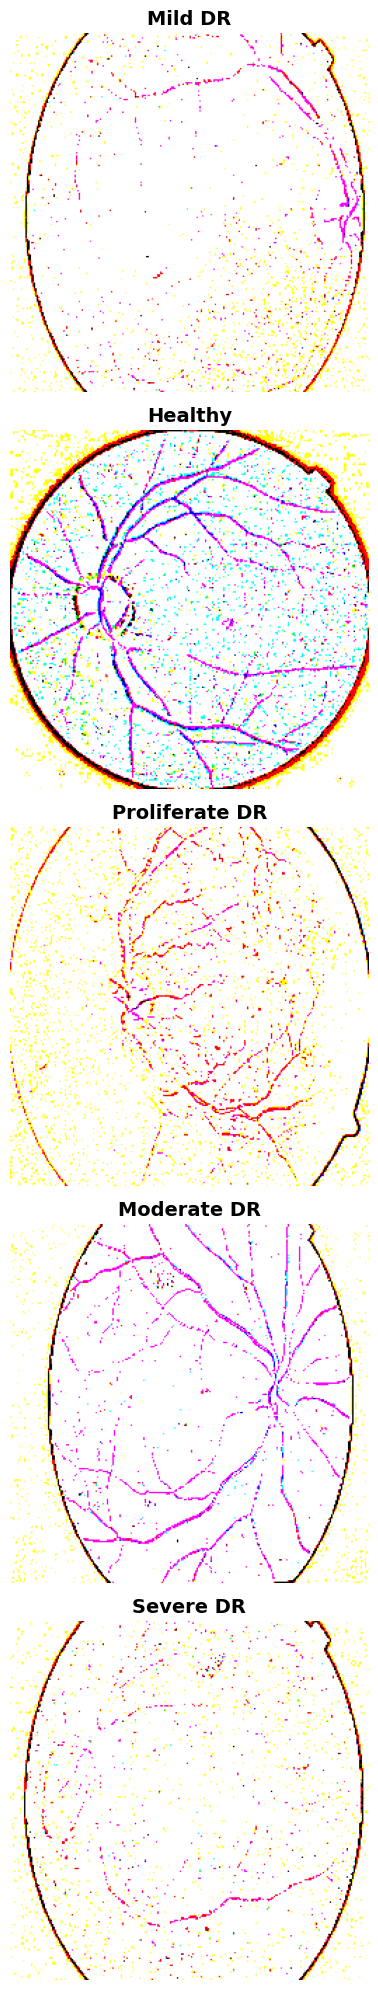

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Display one image per class
def plot_one_per_class_vertical(generator):

    # Get class names
    class_indices = generator.class_indices
    class_names = list(class_indices.keys())

    seen_classes = set()
    images = []
    labels = []

    # Iterate to get one image per class
    for batch_images, batch_labels in generator:
        for img, label in zip(batch_images, batch_labels):
            class_idx = np.argmax(label)
            class_name = class_names[class_idx]
            
            if class_name not in seen_classes:
                seen_classes.add(class_name)
                images.append(img)
                labels.append(class_name)

            if len(seen_classes) == len(class_names):
                break
        if len(seen_classes) == len(class_names):
            break

    # Plot the images with labels
    fig, axes = plt.subplots(len(images), 1, figsize=(6, 4 * len(images)))
    if len(images) == 1:
        axes = [axes]

    for ax, img, label in zip(axes, images, labels):
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(label, fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()


# Call function on the test generator
plot_one_per_class_vertical(test_generator)


## 1. Running a baseline model

In [10]:
# Create a pretty easy besline model based on the example code from class, to get a baseline performance on the data
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy', # Use this loss function here, as it fits the problem at hand
              metrics=['accuracy'])

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

test_loss, test_acc = model.evaluate(test_generator, verbose=2)

Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 45s 992ms/step - accuracy: 0.3137 - loss: 216.9714 - val_accuracy: 0.4396 - val_loss: 1.3979
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 41s 922ms/step - accuracy: 0.4612 - loss: 1.4148 - val_accuracy: 0.4732 - val_loss: 1.3593
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 41s 917ms/step - accuracy: 0.4827 - loss: 1.3616 - val_accuracy: 0.4732 - val_loss: 1.3681
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 41s 921ms/step - accuracy: 0.4878 - loss: 1.2947 - val_accuracy: 0.4698 - val_loss: 1.3563
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 41s 918ms/step - accuracy: 0.4921 - loss: 1.3114 - val_accuracy: 0.4295 - val_loss: 1.3562
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 41s 922ms/step - accuracy: 0.4892 - loss: 1.2873 - val_accuracy: 0.4899 - val_loss: 1.3471
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 43s 979ms/step - accuracy: 0.5108 - loss: 1.2358 - val_accuracy: 0.4933 - val_loss: 1.6661
Epoch 8/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 44s 988ms/step - accuracy: 0.4914 - loss: 1.2400 - val_ac

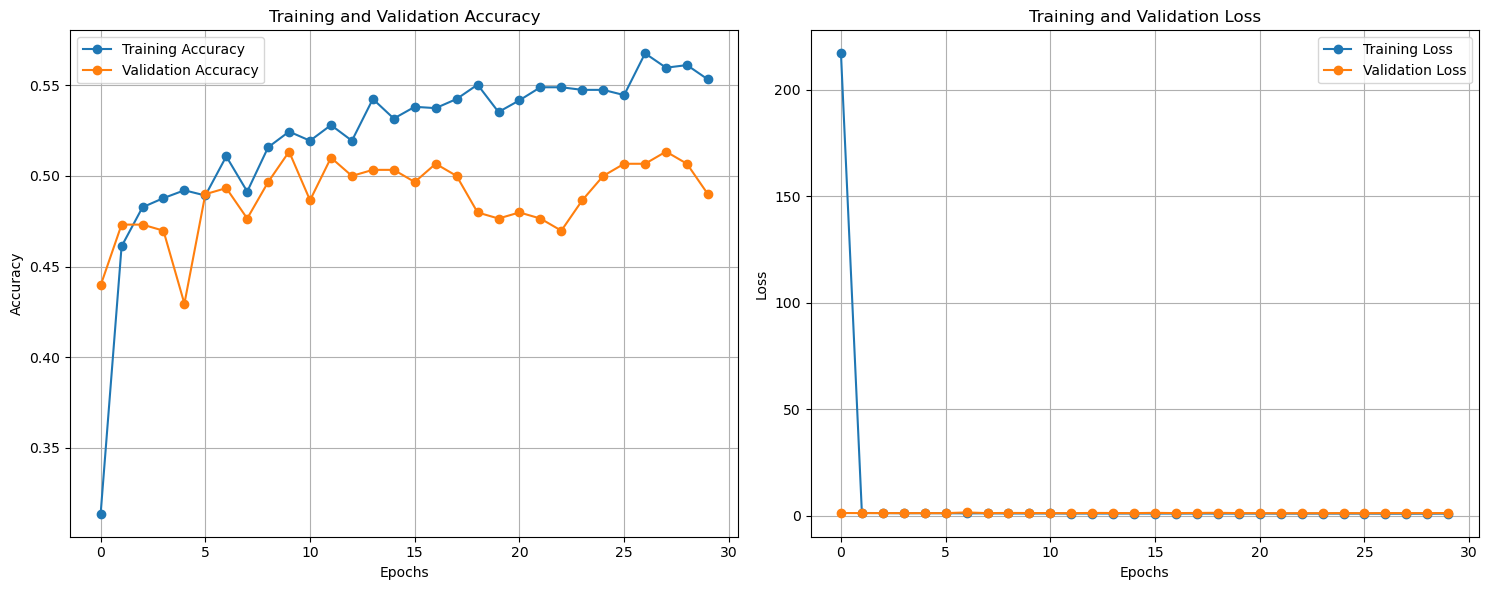

In [11]:
# Plot Accuracy and Loss Curves
def plot_accuracy_and_loss(history):
    plt.figure(figsize=(15, 6))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss', marker='o')
    plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_accuracy_and_loss(history)


In [12]:
# Prediction
true_class = test_generator.classes
predictions = model.predict(test_generator)
predicted_class = np.argmax(predictions, axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step



Model Accuracy: 0.5168

Model Confusion Matrix:
[[66  0 13  0  0]
 [ 2  4 46  1  2]
 [ 4  3 82  1  0]
 [ 0  4 38  0  2]
 [ 0  0 28  0  2]]

Model Classification Report:
                precision    recall  f1-score   support

       Healthy       0.92      0.84      0.87        79
       Mild DR       0.36      0.07      0.12        55
   Moderate DR       0.40      0.91      0.55        90
Proliferate DR       0.00      0.00      0.00        44
     Severe DR       0.33      0.07      0.11        30

      accuracy                           0.52       298
     macro avg       0.40      0.38      0.33       298
  weighted avg       0.46      0.52      0.43       298



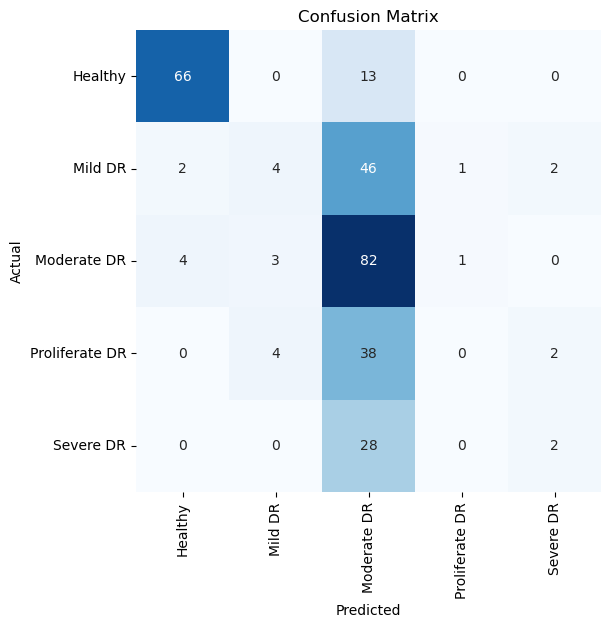

In [13]:
# Show off model performance metrics

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Define the class names
class_names = list(class_counts.keys())

# Model performance metrics
accuracy = accuracy_score(true_class, predicted_class)
precision, recall, f1_score, _ = precision_recall_fscore_support(
    true_class, predicted_class, average='weighted'
)
conf_matrix = confusion_matrix(true_class, predicted_class)
class_report = classification_report(
    true_class, predicted_class, labels=list(range(5)), target_names=class_names
)

# Display the evaluation metrics
print(f"\nModel Accuracy: {accuracy:.4f}")
print(f"\nModel Confusion Matrix:\n{conf_matrix}")
print(f"\nModel Classification Report:\n{class_report}")

# Plot the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', vmin=0, cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


The performance of the baseline model seems to be pretty alright with an accuracy of 51,68%. This means, that the model does successfully identify some differences between the different categories, as the accuracy is significantly above random guessing.

However, looking at the macro F1-Score and above all at the Confusion Matrix, it is pretty clear to see, that the model has big problems classifying some of the not so frequent categories. Most samples get identified as moderate DRs, and almost none get successfully identified as a Proliferate or a severe DR.

This shows, that there is a lot to improve still. A possibility to do so might be to increase the complexity of the model, as this one is not very complex, to see if it catches more finegrained features in the images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..131.32].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..149.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-116.779..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..138.22101].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..149.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..131.32].
Clipping input data

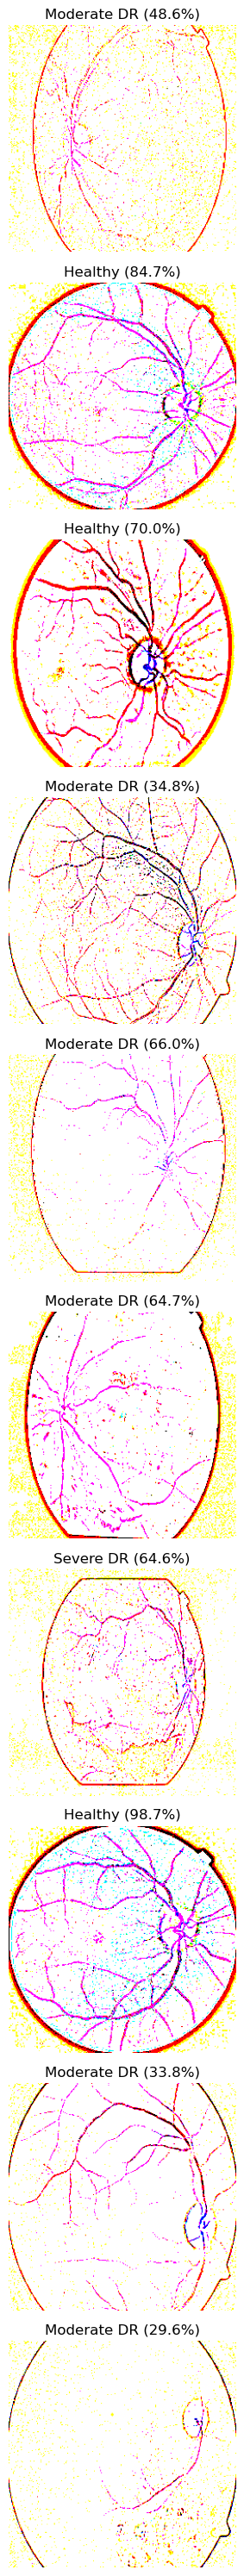

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of test images and labels
test_images, test_labels = next(test_generator)

# Predict probabilities for this batch
pred_probs = model.predict(test_images)
pred_classes = np.argmax(pred_probs, axis=-1)  # predicted class indices

# Class names
class_names = list(test_generator.class_indices.keys())

# Function to plot images vertically with predicted probabilities
def plotImages(images, pred_classes, pred_probs, class_names):
    fig, axes = plt.subplots(len(images), 1, figsize=(5, len(images)*3))
    if len(images) == 1:
        axes = [axes]
    for img, pred_class, probs, ax in zip(images, pred_classes, pred_probs, axes):
        ax.imshow(img)
        ax.axis('off')
        prob = np.max(probs)
        ax.set_title(f"{class_names[pred_class]} ({prob*100:.1f}%)")
    plt.tight_layout()
    plt.show()

# Plot first 10 images from the batch
plotImages(test_images[:10], pred_classes[:10], pred_probs[:10], class_names)


## 2. Adapted Model

In [15]:
from tensorflow.keras import models, layers, callbacks

# Create a deeper baseline model with batch normalization and dropout to reduce overfitting
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',  # Suitable for multi-class classification
              metrics=['accuracy'])

# Early stopping callback to stop training if validation loss doesn't improve for 5 consecutive epochs
# This is done in order to avoid things such as overfitting
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_generator,
    epochs=30,  # Increased number of epochs for better training opportunity
    validation_data=val_generator,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator),
    callbacks=[early_stopping]
)


Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.3763 - loss: 18.1857 - val_accuracy: 0.4262 - val_loss: 16.8455
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.4266 - loss: 2.1483 - val_accuracy: 0.4228 - val_loss: 2.3355
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.4086 - loss: 1.5625 - val_accuracy: 0.4698 - val_loss: 1.5891
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.3928 - loss: 1.5980 - val_accuracy: 0.4530 - val_loss: 1.6991
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.3806 - loss: 1.5143 - val_accuracy: 0.4128 - val_loss: 2.0084
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.3863 - loss: 1.5079 - val_accuracy: 0.3758 - val_loss: 1.8274
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.3957 - loss: 1.5375 - val_accuracy: 0.3356 - val_loss: 1.5846
Epoch 8/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.3755 - loss: 1.5263 - val_accuracy: 0.3121 - val_los

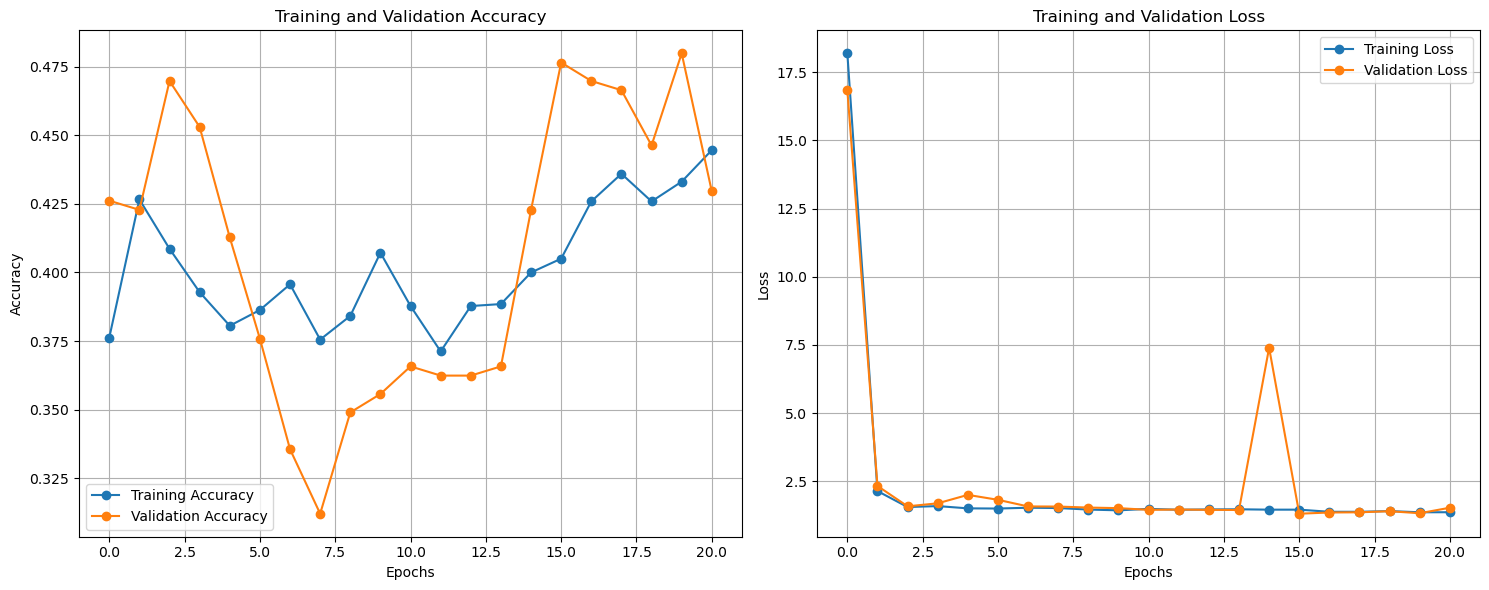

In [16]:
# Plot Accuracy and Loss Curves

plot_accuracy_and_loss(history)


In [17]:
# Prediction
true_class = test_generator.classes
predictions = model.predict(test_generator)
predicted_class = np.argmax(predictions, axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 270ms/step



Model Accuracy: 0.5134

Model Confusion Matrix:
[[67  1 11  0  0]
 [ 3  0 52  0  0]
 [ 4  0 86  0  0]
 [ 2  0 42  0  0]
 [ 2  1 27  0  0]]

Model Classification Report:
                precision    recall  f1-score   support

       Healthy       0.86      0.85      0.85        79
       Mild DR       0.00      0.00      0.00        55
   Moderate DR       0.39      0.96      0.56        90
Proliferate DR       0.00      0.00      0.00        44
     Severe DR       0.00      0.00      0.00        30

      accuracy                           0.51       298
     macro avg       0.25      0.36      0.28       298
  weighted avg       0.35      0.51      0.39       298



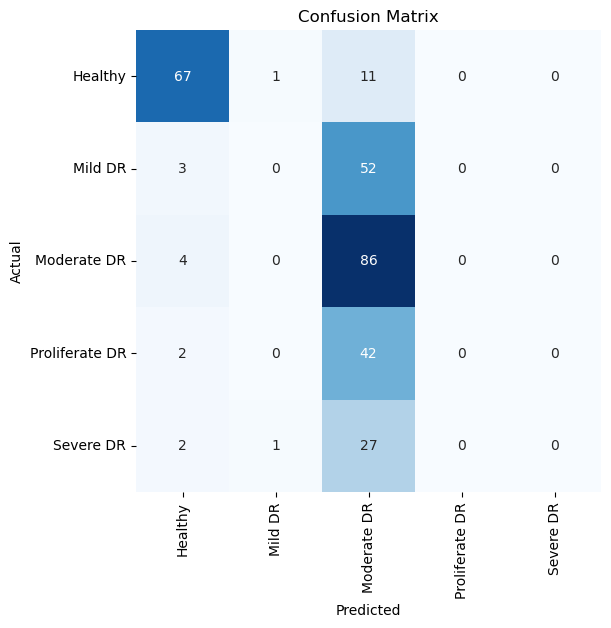

In [18]:
# Show off model performance metrics

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Define the 5 class names
class_names = list(class_counts.keys())

# Model performance metrics
accuracy = accuracy_score(true_class, predicted_class)
precision, recall, f1_score, _ = precision_recall_fscore_support(
    true_class, predicted_class, average='weighted'
)
conf_matrix = confusion_matrix(true_class, predicted_class)
class_report = classification_report(
    true_class, predicted_class, labels=list(range(5)), target_names=class_names
)

# Display the evaluation metrics
print(f"\nModel Accuracy: {accuracy:.4f}")
print(f"\nModel Confusion Matrix:\n{conf_matrix}")
print(f"\nModel Classification Report:\n{class_report}")

# Plot the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', vmin=0, cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Different from what was expected, the deeper model structure fails to gain more insights into the images. The classification of the images gets even worse, not better, in terms of accuracy.

It seems, like there are not enough images for such a deep model structure to be helpful. The model performance overall is worse than of the baseline model.

Another approach might be to use the lower model structure, but to address the unbalanced data by using the class weights.

## 3. Model with class weights

In [19]:
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Trying to improve performance by adding class weights
# Compute class weights from the training generator
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

# Convert to dictionary
class_weights = dict(enumerate(class_weights))
print("Computed Class Weights:", class_weights)

# Define the same architecture as the baseline model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model with class weights
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=30,
    validation_data=test_generator,
    validation_steps=len(test_generator),
    class_weight=class_weights,   # this line adds balancing
    callbacks=[early_stopping]
)

# Evaluate model
test_loss, test_acc = model.evaluate(test_generator, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")


Computed Class Weights: {0: np.float64(0.7554347826086957), 1: np.float64(1.0733590733590734), 2: np.float64(0.6634844868735084), 3: np.float64(1.3694581280788178), 4: np.float64(1.9716312056737588)}
Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 41s 920ms/step - accuracy: 0.3223 - loss: 176.7650 - val_accuracy: 0.4732 - val_loss: 1.2696
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 41s 921ms/step - accuracy: 0.4590 - loss: 1.3408 - val_accuracy: 0.4463 - val_loss: 1.2736
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 41s 923ms/step - accuracy: 0.4446 - loss: 1.3174 - val_accuracy: 0.4329 - val_loss: 1.2157
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 40s 913ms/step - accuracy: 0.4655 - loss: 1.2634 - val_accuracy: 0.4664 - val_loss: 1.2005
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 41s 919ms/step - accuracy: 0.4604 - loss: 1.2284 - val_accuracy: 0.4195 - val_loss: 1.3116
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 41s 918ms/step - accuracy: 0.4547 - loss: 1.2563 - val_accuracy: 0.4262 - val_loss: 1.2237
Epoch 7/30
44/44 ━━━━━━━

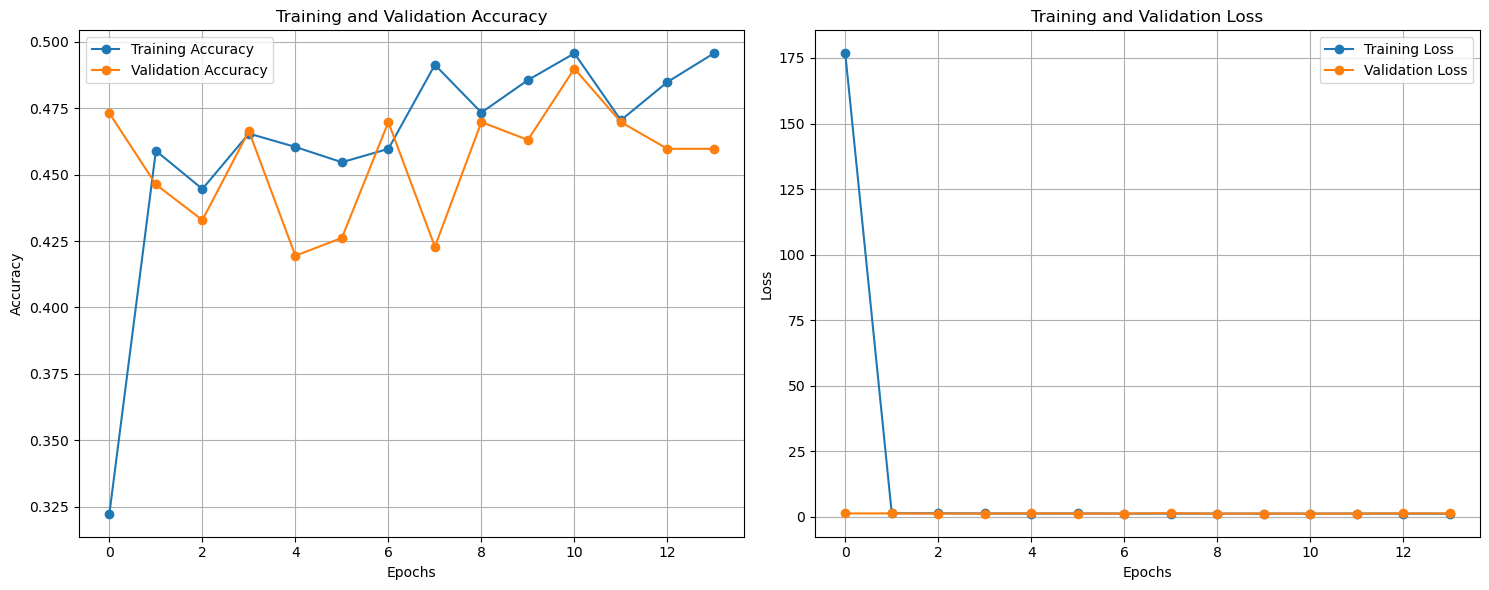

In [20]:
# Plot Accuracy and Loss Curves

plot_accuracy_and_loss(history)


In [21]:
# Prediction
true_class = test_generator.classes
predictions = model.predict(test_generator)
predicted_class = np.argmax(predictions, axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 227ms/step



Model Accuracy: 0.4698

Model Confusion Matrix:
[[69  6  1  1  2]
 [ 2 41  2  4  6]
 [ 8 31 15 26 10]
 [ 0 20  9 11  4]
 [ 1 11  6  8  4]]

Model Classification Report:
                precision    recall  f1-score   support

       Healthy       0.86      0.87      0.87        79
       Mild DR       0.38      0.75      0.50        55
   Moderate DR       0.45      0.17      0.24        90
Proliferate DR       0.22      0.25      0.23        44
     Severe DR       0.15      0.13      0.14        30

      accuracy                           0.47       298
     macro avg       0.41      0.43      0.40       298
  weighted avg       0.48      0.47      0.44       298



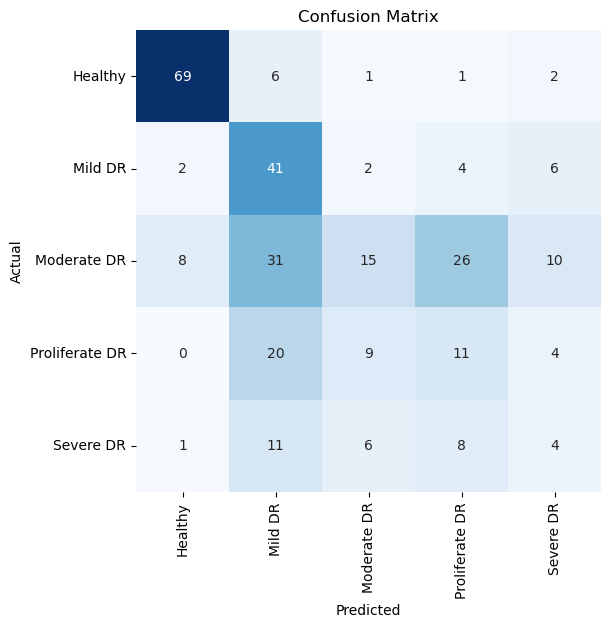

In [22]:
# Show off model performance metrics

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Define the 5 class names
class_names = list(class_counts.keys())

# Model performance metrics
accuracy = accuracy_score(true_class, predicted_class)
precision, recall, f1_score, _ = precision_recall_fscore_support(
    true_class, predicted_class, average='weighted'
)
conf_matrix = confusion_matrix(true_class, predicted_class)
class_report = classification_report(
    true_class, predicted_class, labels=list(range(5)), target_names=class_names
)

# Display the evaluation metrics
print(f"\nModel Accuracy: {accuracy:.4f}")
print(f"\nModel Confusion Matrix:\n{conf_matrix}")
print(f"\nModel Classification Report:\n{class_report}")

# Plot the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', vmin=0, cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


At first glance, it seems like this model is doing worse than the previous two, due to a lower accuracy score. However, it also has the highest F1-Score (0.44) out of the three, and it is thus clear that the lower accuracy ist just because the first two models mainly classify all images as Moderate DRs, the most frequent class.

The accuracy of the model is still too bad to actually use it. Another possibility to increase the performance of the model might be to use a pretrained model, and just finetune it on the data available. This solves the problem of insufficient data.

## 4. Pretrained Model 1: ResNet50

ResNet50 is a pretrained model, which consists of 49 convolutional layers and 1 fully connected layer. It is widely used for image classification, and is often used as the pretrained backbone for a strong model, especially when there is not enough data available to train a deep model from scratch.

It was trained on 1.3 million training images, with 1000 different object categories, and has thus a very broad understanding of images in general.

In [37]:
from tensorflow.keras.applications import ResNet50

# Load ResNet50 base
# The basemodel acts as a feature extractor, converts the image into a feature map
base_model = ResNet50(weights='imagenet', include_top=False,
                      input_shape=(256, 256, 3))
base_model.trainable = False  # Freeze pretrained layers

# Build model with minimum layers after pretrained model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),   # Need to flatten feature maps
    layers.Dense(num_classes, activation='softmax')  # Output layer
])

# Compile
optimizer = optimizer='adam'
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callback
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                         restore_best_weights=True, verbose=1)

# Train
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

# Fine-tuning, unfreeze the last 30 layers of ResNet50 to fine-tune them
# Adapt the net specific to the medical dataset
from tensorflow.keras.optimizers import Adam

# Fine-tuning, unfreeze the last 30 layers of ResNet50 to fine-tune them
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Set a lower learning rate for fine-tuning
low_lr_optimizer = Adam(learning_rate=1e-5)

# Recompile the best model from before with low learning rate
model.compile(optimizer=low_lr_optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Retrain the model
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    verbose=1
)


Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 157s 3s/step - accuracy: 0.4331 - loss: 1.3805 - val_accuracy: 0.4899 - val_loss: 1.2646
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step - accuracy: 0.5317 - loss: 1.1495 - val_accuracy: 0.4933 - val_loss: 1.2393
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - accuracy: 0.5899 - loss: 1.0494 - val_accuracy: 0.5067 - val_loss: 1.1465
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 148s 3s/step - accuracy: 0.6144 - loss: 0.9759 - val_accuracy: 0.4933 - val_loss: 1.1383
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 150s 3s/step - accuracy: 0.6295 - loss: 0.9471 - val_accuracy: 0.5570 - val_loss: 1.0630
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.6353 - loss: 0.9203 - val_accuracy: 0.5470 - val_loss: 1.0629
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 146s 3s/step - accuracy: 0.6345 - loss: 0.9233 - val_accuracy: 0.6107 - val_loss: 0.9520
Epoch 8/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 145s 3s/step - accuracy: 0.6439 - loss: 0.9083 - val_accuracy: 0.5638 - v

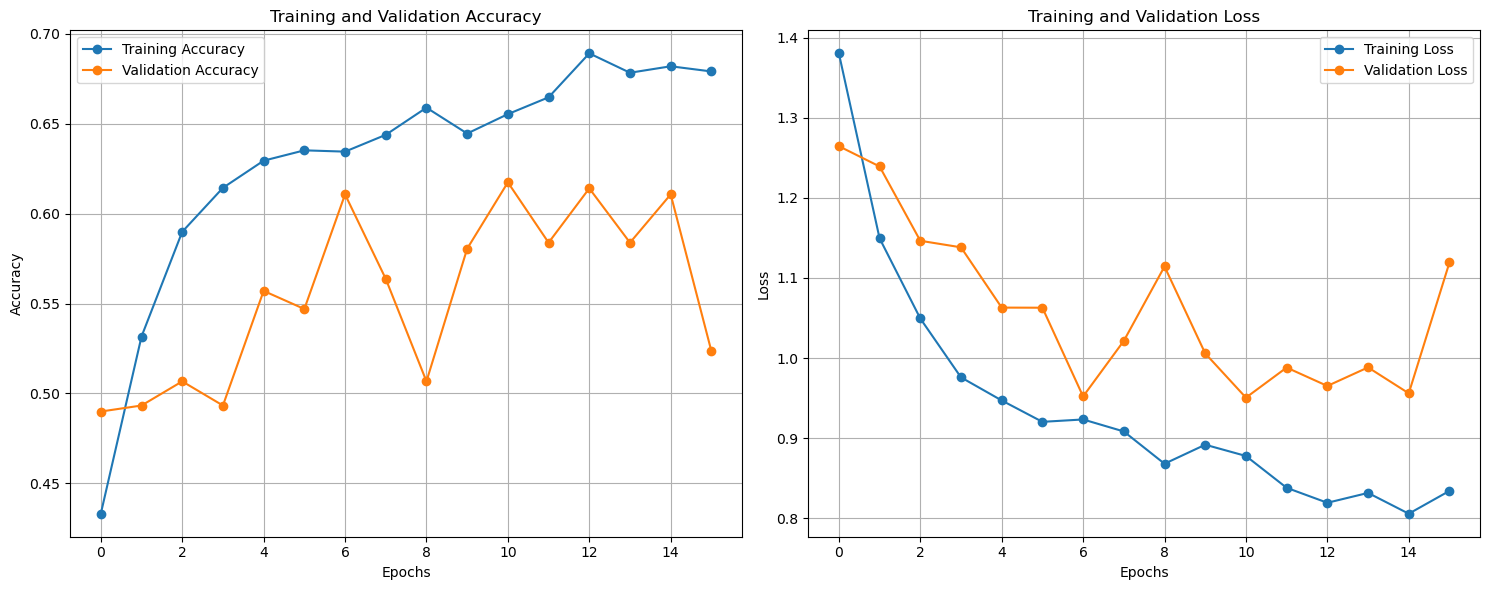

In [38]:
# Plot Accuracy and Loss Curves

plot_accuracy_and_loss(history)

In [39]:
# Prediction
true_class = test_generator.classes
predictions = model.predict(test_generator)
predicted_class = np.argmax(predictions, axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step



Model Accuracy: 0.6577

Model Confusion Matrix:
[[72  6  1  0  0]
 [ 3 41  9  0  2]
 [ 3 12 60  1 14]
 [ 0  6 16  7 15]
 [ 0  3  9  2 16]]

Model Classification Report:
                precision    recall  f1-score   support

       Healthy       0.92      0.91      0.92        79
       Mild DR       0.60      0.75      0.67        55
   Moderate DR       0.63      0.67      0.65        90
Proliferate DR       0.70      0.16      0.26        44
     Severe DR       0.34      0.53      0.42        30

      accuracy                           0.66       298
     macro avg       0.64      0.60      0.58       298
  weighted avg       0.68      0.66      0.64       298



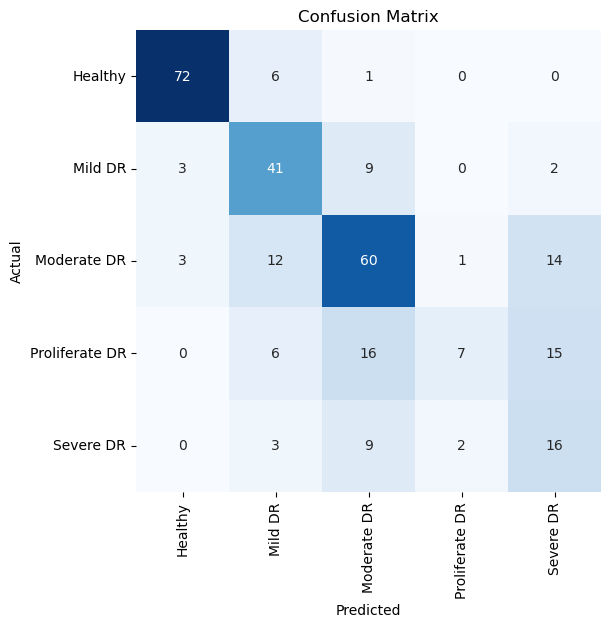

In [40]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Define 5 class names
class_names = list(class_counts.keys())

# Model performance metrics
accuracy = accuracy_score(true_class, predicted_class)
precision, recall, f1_score, _ = precision_recall_fscore_support(
    true_class, predicted_class, average='weighted'
)
conf_matrix = confusion_matrix(true_class, predicted_class)
class_report = classification_report(
    true_class, predicted_class, labels=list(range(5)), target_names=class_names
)

# Display the evaluation metrics
print(f"\nModel Accuracy: {accuracy:.4f}")
print(f"\nModel Confusion Matrix:\n{conf_matrix}")
print(f"\nModel Classification Report:\n{class_report}")

# Plot the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', vmin=0, cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


This model performs by far the best out of the models so far. An accuracy of 65.77% suggest a pretty good performance in comparison to the rest, and also a higher F1-Score shows that the model actually does recognize the different classes fairly well. 

The confusion matrix shows that, contrary to the other models, this one does not classify the great majority of the images as a Moderate DR, but has a pretty good rate of correctly classifying the different minority classes.

This is due to the fact that the class weights were used here, but also due to the ResNet50 structure used as a pretrained backbone for the model. As the total data is very limited with a total of 2000 images, this is also a reason why the pretrained model achieves a better performance than the ones only trained on the data. There is just not enough data, to correctly identify structures in the different classes. And the pretrained model helps here, because it already has a lot of patterns saved on deeper levels, which it got from the huge amount of data it was trained on, and now only has to transfer its knowledge to this specific problem.

## 5. Pretrained Model 2: EfficientNetB0

EfficientNetB0 is another pretrained model architecture for image classification. It is a pretty lightweight model with fewer parameters than ResNet for example. It is widely used in computer vision tasks as a backbone for transfer learning. Just like ResNet50, it is able to classify into 1000 different classes initially.


In [33]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, optimizers, callbacks

# Load EfficientNetB0 base (exclude top)
base_model = EfficientNetB0(weights='imagenet', include_top=False,
                           input_shape=(256, 256, 3))
base_model.trainable = False  # Freeze base

# Build model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(num_classes, activation='softmax')
])

# Compile
optimizer = 'adam'
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
lr_scheduler = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                           patience=3, min_lr=1e-6, verbose=1)
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                         restore_best_weights=True, verbose=1)

# Train
history = model.fit(
    train_generator,
    validation_data=val_generator,  # use val_generator here
    epochs=30,
    class_weight=class_weights,
    callbacks=[lr_scheduler, early_stopping],
    verbose=1
)

# Fine-tuning (unfreeze last 30 layers)
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(
    train_generator,
    validation_data=val_generator,  # use val_generator here
    epochs=10,
    class_weight=class_weights,
    verbose=1
)

# Evaluate
test_loss, test_acc = model.evaluate(test_generator, verbose=2)
print(f"\nEfficientNetB0 Test Accuracy: {test_acc:.4f}")


Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.4094 - loss: 1.3952 - val_accuracy: 0.3792 - val_loss: 1.3027 - learning_rate: 0.0010
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.4878 - loss: 1.1948 - val_accuracy: 0.5000 - val_loss: 1.1826 - learning_rate: 0.0010
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.5532 - loss: 1.1133 - val_accuracy: 0.5235 - val_loss: 1.1418 - learning_rate: 0.0010
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.5676 - loss: 1.0739 - val_accuracy: 0.5537 - val_loss: 1.1130 - learning_rate: 0.0010
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.5835 - loss: 1.0511 - val_accuracy: 0.5671 - val_loss: 1.0879 - learning_rate: 0.0010
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.5935 - loss: 1.0343 - val_accuracy: 0.5369 - val_loss: 1.0958 - learning_rate: 0.0010
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.6014 - loss: 1.0056 - val_accuracy: 

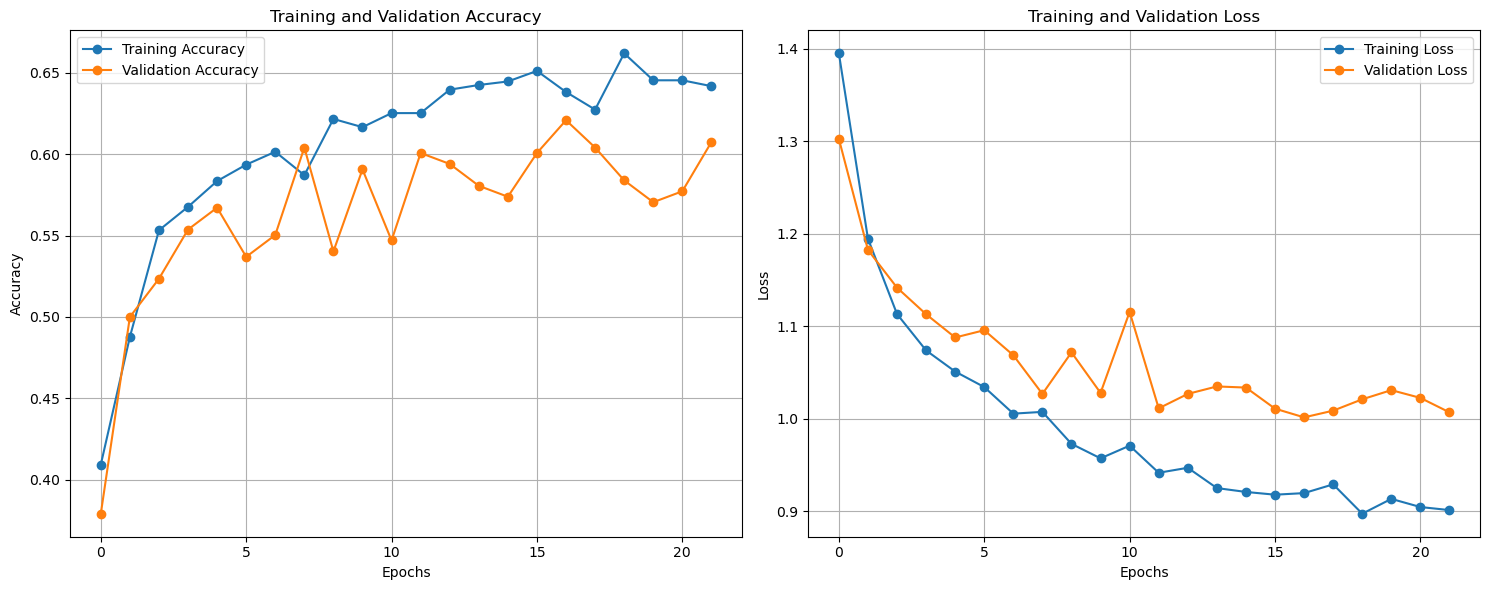

In [34]:
# Plot Accuracy and Loss Curves

plot_accuracy_and_loss(history)

In [35]:
# Prediction
true_class = test_generator.classes
predictions = model.predict(test_generator)
predicted_class = np.argmax(predictions, axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step



Model Accuracy: 0.6141

Model Confusion Matrix:
[[78  1  0  0  0]
 [ 6 40  3  1  5]
 [ 4 19 37 13 17]
 [ 0  7  8 17 12]
 [ 0  4  9  6 11]]

Model Classification Report:
              precision    recall  f1-score   support

      Class1       0.89      0.99      0.93        79
      Class2       0.56      0.73      0.63        55
      Class3       0.65      0.41      0.50        90
      Class4       0.46      0.39      0.42        44
      Class5       0.24      0.37      0.29        30

    accuracy                           0.61       298
   macro avg       0.56      0.58      0.56       298
weighted avg       0.63      0.61      0.61       298



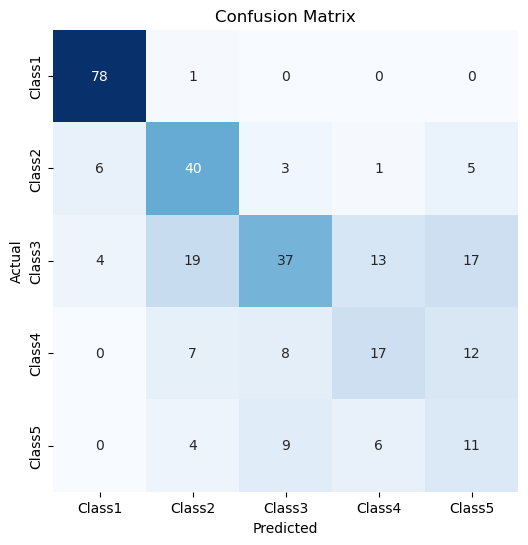

In [36]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Define 5 class names
class_names = list(class_counts.keys())

# Model performance metrics
accuracy = accuracy_score(true_class, predicted_class)
precision, recall, f1_score, _ = precision_recall_fscore_support(
    true_class, predicted_class, average='weighted'
)
conf_matrix = confusion_matrix(true_class, predicted_class)
class_report = classification_report(
    true_class, predicted_class, labels=list(range(5)), target_names=class_names
)

# Display the evaluation metrics
print(f"\nModel Accuracy: {accuracy:.4f}")
print(f"\nModel Confusion Matrix:\n{conf_matrix}")
print(f"\nModel Classification Report:\n{class_report}")

# Plot the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', vmin=0, cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


The model on EfficientNetB0 does, just like the ResNet50 one, clearly outperform the models trained from scratch, due to the same reasons. It does not outperform the ResNet50 model, as it especially has a problem with correctly classifying the moderate DR class, getting the lowest F1-Score for that category.

## Conclusion

In this project, multiple CNNS were evaluated on the Diabetic Retinopathy dataset, which consists of five imbalanced classes ranging from healthy to severe DR cases. The baseline CNN model taken from class achieved moderate performance with an accuracy of about 52%, but struggled to correctly classify the less frequent, more severe classes, as shown by the confusion matrix and F1-scores.

Increasing the depth and complexity of the model did not yield better results, likely due to the limited size and imbalance of the dataset, which caused overfitting and a bias towards the majority classes.

Introducing class weights during training helped address class imbalance, improving the recognition of minority classes by the model despite a slight drop in overall accuracy. This suggests that balanced learning helps with imbalanced datasets.

Finally, transfer learning with pretrained architectures (ResNet50 and EfficientNetB0) significantly improved model performance. ResNet50 achieved the highest accuracy with 65.77% and balanced class predictions, benefitting from the prior training on a large dataset. EfficientNetB0 also showed strong results, although it struggled somewhat with the moderate DR class.

In conclusion, this project shows the importance of addressing data imbalance and using pretrained models for image classification tasks with limited labeled data. As with the low amount of data, the models trained from scratch do not achieve a good performance, using these pretrained models can help enrich the patterns recognized in the images.

As for this specific case, even the model performing the best, at an accuracy of 65.77% can possibly only used as a helpful tool to help the doctors get a direction of what this image might be. The final classification has to be done by a human expert, as an accuracy of this level is way too low in medical fields, where the diagnosis is important an can possibly impact peopoles lives.

For the future, in order to improve the performance of the models and make them actually useful, there is above all one thing that is needed: More data. Based on more data, deeper CNNs can be trained, recognizing more fine-grained patterns in the images and achieving higher accuracy.